<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_LAB1/Laboratorio_N%C2%B01_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiencia 3 - Optimización de mezclas de hormigón para obra civil

##0. Consideraciones y configuracion del entorno

Estas son las consideraciones iniciales que debemos tener en cuenta a la hora de entrenar el modelo y buscar soluciones a nuestra problematica.

Objetivos:
- Reducir costo de mezclas de hormigón
- Cumplir con los requisitos mínimos de MPa.
- Compensar cemento con agregados.

Información previa:
- El cemento tiene una relacion lineal con el MPa
- Los agregados tienen una relacion no lineal con el MPa

Riesgos del *target*:
- Subestimar la resistencia es un costo extra innecesario
- Sobreestimar la resistencia es un error estructural fatal

In [24]:
# @title #####Configuracion del entorno

# Importaciones
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Modulos no instalados
!pip install lazypredict
from lazypredict.Supervised import LazyRegressor

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Entorno configurado.")

Entorno configurado.


##1. Carga y exploracion inicial

###1.1 Carga de datos

In [25]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
if not os.path.exists("datos_ccs.zip"):
  !wget https://github.com/AxelSkrauba/applied-ai-engineering/raw/main/datasets/ccs/datos_ccs.zip

In [26]:
if not os.path.exists("datos_ccs.csv"):
    !unzip datos_ccs.zip
df_ccs = pd.read_csv("datos_ccs.csv")

###1.2 Inspeccion inicial y calidad de datos

In [27]:
print(f"Dimensiones: {df_ccs.shape}")
print(f"\nTipos de datos:\n{df_ccs.dtypes}")
print(f"\nFaltantes: {df_ccs.isnull().sum().sum()} (ninguno)")
print(f"\nPrimeras filas:")
df_ccs

Dimensiones: (1030, 9)

Tipos de datos:
cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object

Faltantes: 0 (ninguno)

Primeras filas:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


In [28]:
print("Detectando valores negativos:")
negative_values_found = False
for column in df_ccs.columns:
    if (df_ccs[column] < 0).any():
        negative_values_found = True
        print(f"  - La columna '{column}' contiene valores negativos.")
        print(df_ccs[df_ccs[column] < 0][column])

if not negative_values_found:
    print("  - No se encontraron valores negativos en el dataset.")

Detectando valores negativos:
  - No se encontraron valores negativos en el dataset.


##2. Análisis exploratorio orientado al problema

In [29]:
# @title Tabla de media, desviación estándar y coeficiente de variación (CV)
columnas_numericas = df_ccs.select_dtypes(include=['number']).columns

# Calcular la media y la desviaci3n est1ndar para cada columna num1rica
valores_media = df_ccs[columnas_numericas].mean()
valores_desviacion = df_ccs[columnas_numericas].std()

# CV = Desviaci3n Est1ndar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados
medidas_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
})

# Obtener el orden de las columnas basado en CV (excluyendo csMPa)
columnas_ordenadas_cv = cv.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_cv + ['csMPa']

# Transponer y reordenar
medidas_df = medidas_df.T[columns_order]

# Mostrar el DataFrame
display(medidas_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,slag,flyash,age,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,73.895825,54.188350,45.662136,35.817961
Desviación Estándar,77.753954,80.175980,21.354219,104.506364,5.973841,86.279342,63.997004,63.169912,16.705742
Coeficiente de Variación,0.079918,0.103643,0.117610,0.371687,0.962799,1.167581,1.181010,1.383420,0.466407


- Poca variacion en el agua y agregados (base constante).
- Variacion moderada en cemento.
- Gran variacion en aditivos y edad.

In [30]:
# @title Tabla de media, mediana, Dif. Absoluta, Dif. Porcentual de cada variable.
# Calcular la media y la mediana para cada columna numérica
valores_mediana = df_ccs[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - valores_mediana).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': valores_mediana,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
})

columnas_ordenadas_dp = diferencia_porcentual.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_dp + ['csMPa']

diferencia_df = diferencia_df.T[columns_order]

display(diferencia_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,age,slag,flyash,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,45.662136,73.895825,54.18835,35.817961
Mediana,968.000000,779.500000,185.000000,272.900000,6.400000,28.000000,22.000000,0.00000,34.445000
Diferencia Absoluta (Media - Mediana),4.918932,5.919515,3.432718,8.267864,0.195340,17.662136,51.895825,54.18835,1.372961
Diferencia Porcentual (%),0.505585,0.765210,1.890604,2.940544,3.148276,38.680048,70.228359,100.00000,3.833164


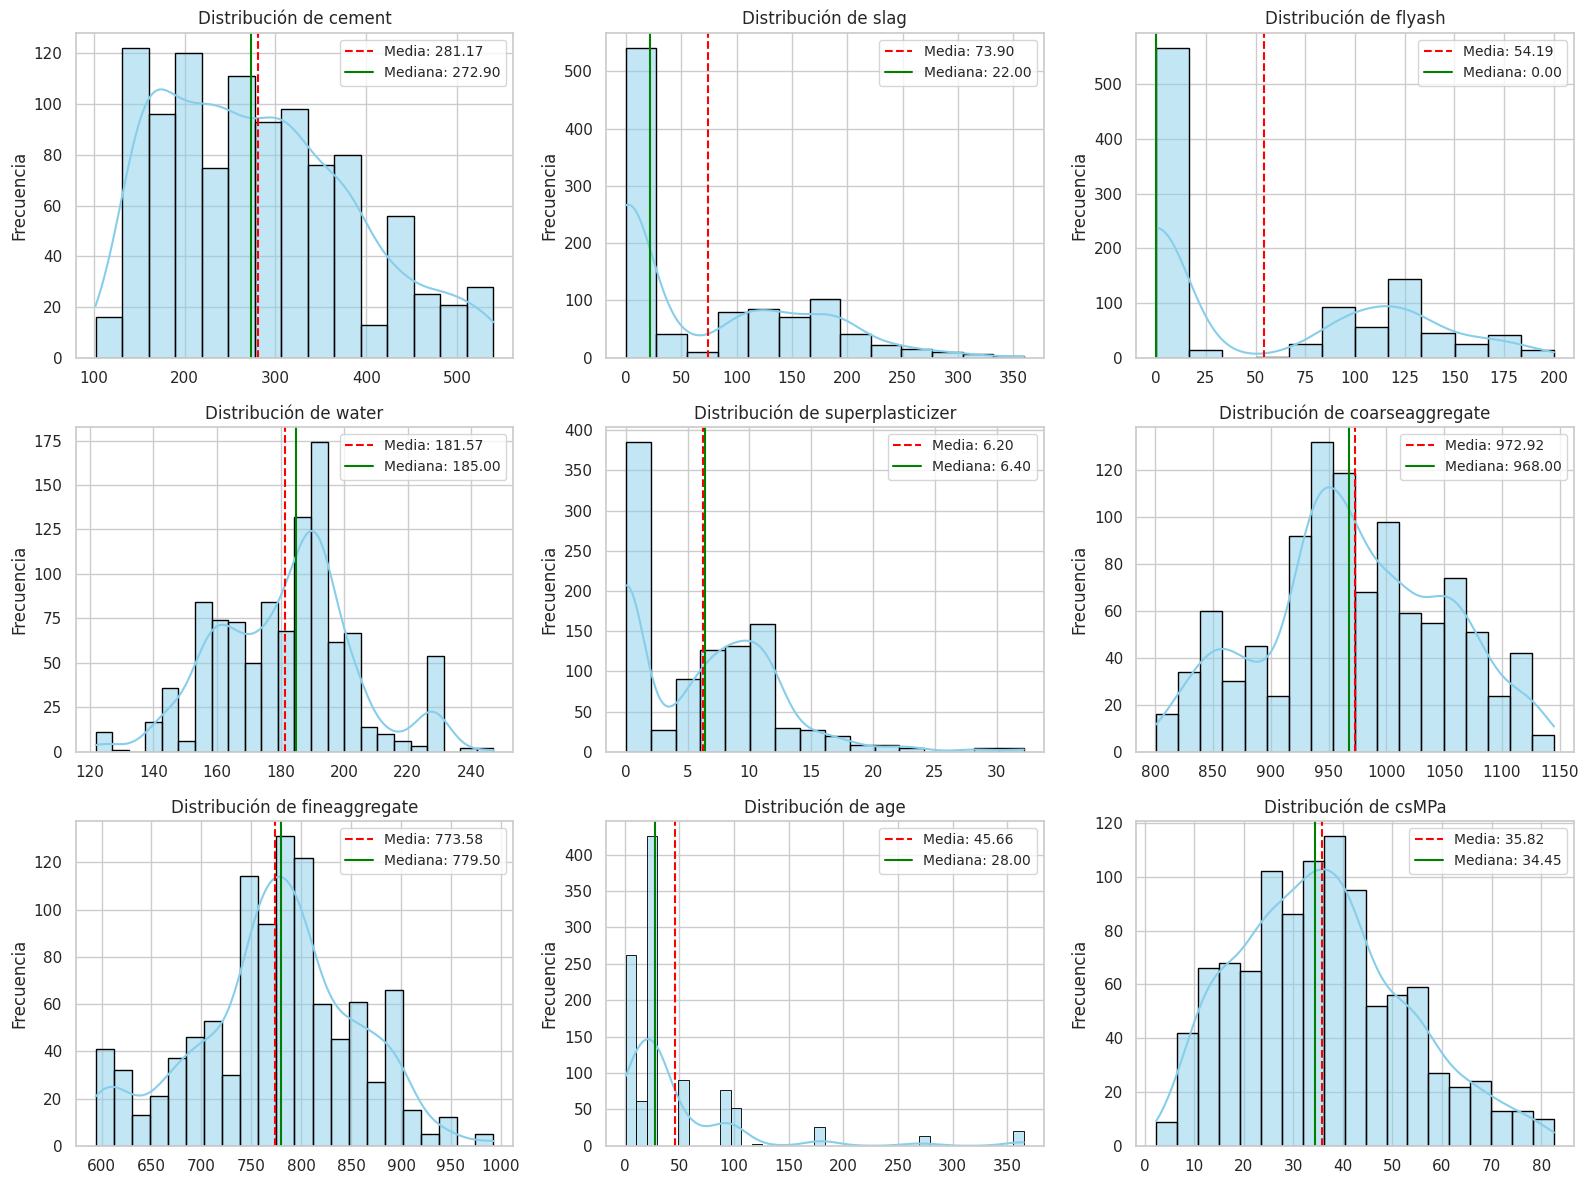

In [31]:
# @title Histogramas de distribución para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.histplot(df_ccs[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')

    # Calcular media y mediana
    mean_val = df_ccs[col].mean()
    median_val = df_ccs[col].median()

    # Agregar líneas de referencia
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize='small')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Distribucion simetrica en `coarseaggregate`, `fineaggregate	` y `water`.
- Distribucion ligeramente sesgada (hacia la derecha) en `cement` y `csMPa`.
- Distribucion altamente sesgada (hacia la derecha) en `age`.
- Distribucion bimodal en `slag`, `flyash` y `superplasticizer`.



Distribuciones

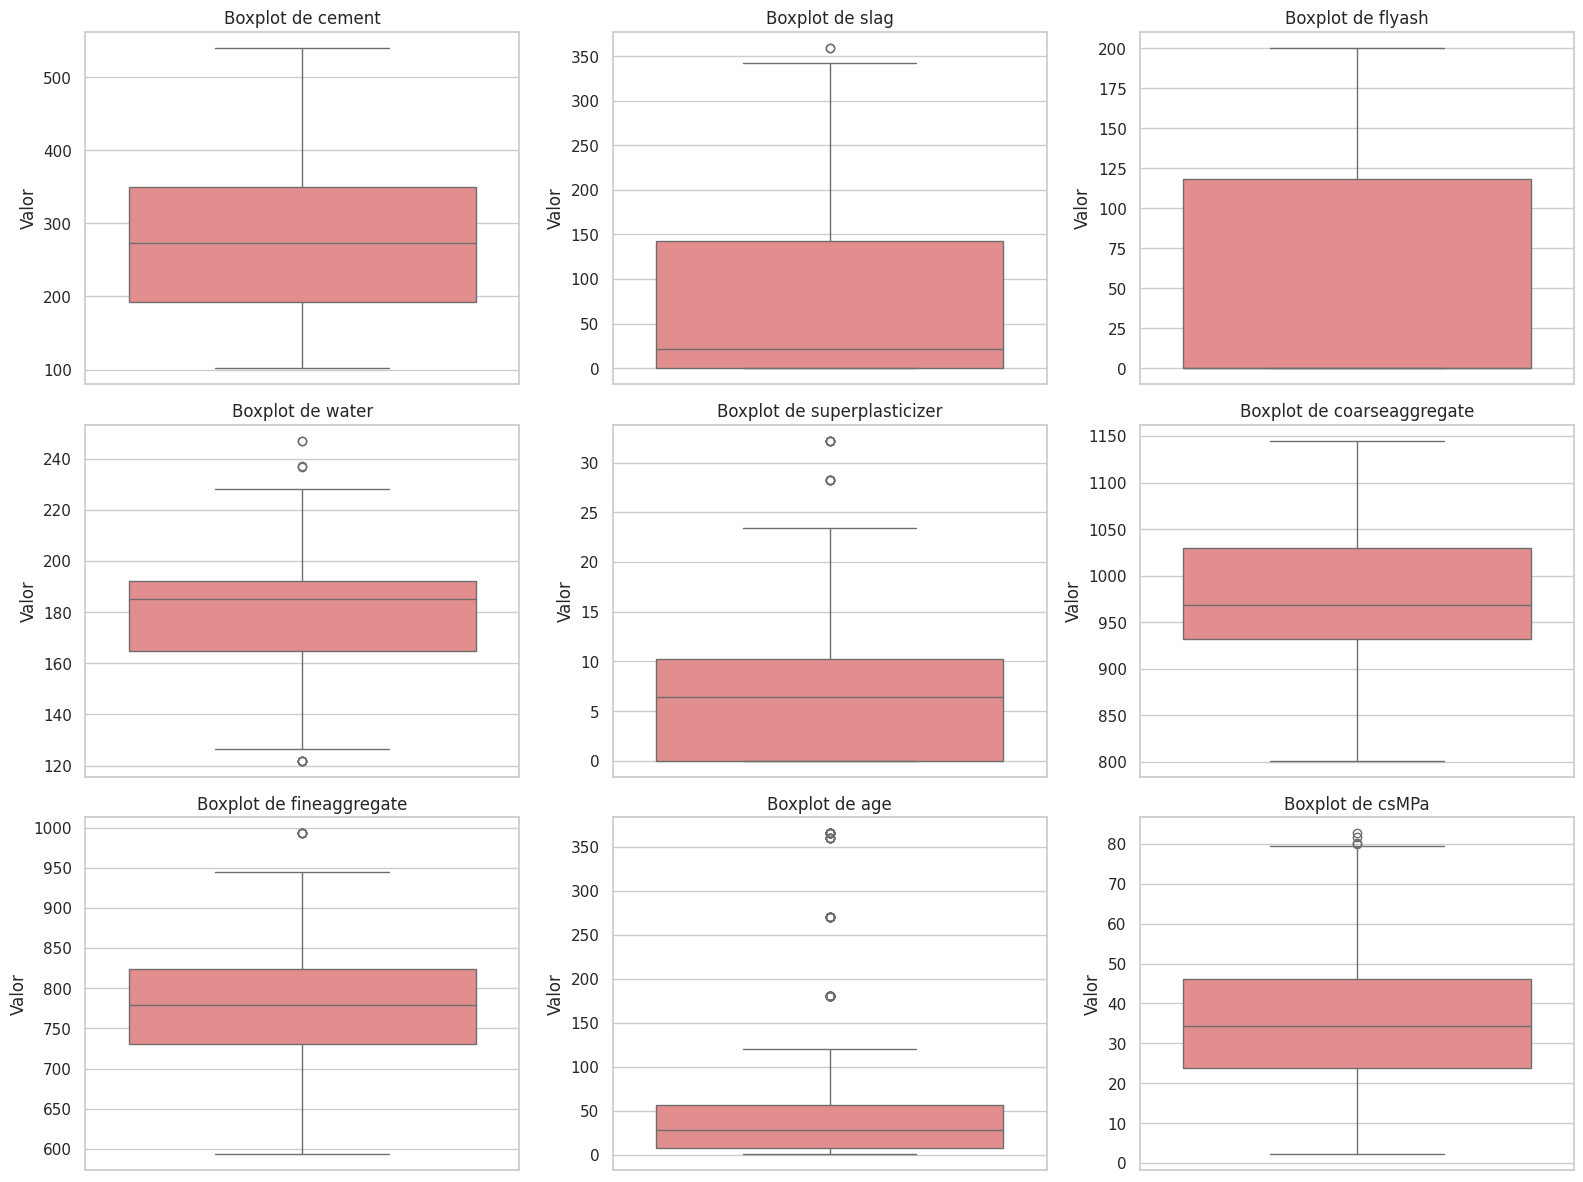

In [32]:
# @title Diagramas de caja (Boxplots) para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.boxplot(y=df_ccs[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel('Valor')
    axes[i].set_xlabel('')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [33]:
# Calcular IQR para csMPa
Q1 = df_ccs['csMPa'].quantile(0.25)
Q3 = df_ccs['csMPa'].quantile(0.75)
IQR = Q3 - Q1
inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers_csMPa = df_ccs[(df_ccs['csMPa'] < inferior) | (df_ccs['csMPa'] > superior)]

print(f"Límite inferior: {inferior:.2f}")
print(f"Límite superior: {superior:.2f}")
print(f"Total de outliers detectados: {len(outliers_csMPa)}")

outliers_csMPa.sort_values(by='csMPa', ascending=False)

Límite inferior: -9.93
Límite superior: 79.77
Total de outliers detectados: 4


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
181,389.9,189.0,0.0,145.9,22.0,944.7,755.8,91,82.60
381,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28,81.75
153,323.7,282.8,0.0,183.8,10.3,942.7,659.9,56,80.20
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99


Los valores tienen sentido aparente

In [34]:
# @title Prototipado Rápido

# 1. Preparación de datos para entrenamiento
X = df_ccs.drop(columns=['csMPa'])
y = df_ccs['csMPa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# 2. Inicializar y entrenar LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# 3. Mostrar resultados (Todos los modelos)
print("Comparativa completa de modelos evaluados:")
pd.set_option('display.max_rows', None)  # Asegurar que se muestren todos en el notebook
display(models)

Comparativa completa de modelos evaluados:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
XGBRegressor,0.914312,0.917656,4.606305,0.869411
HistGradientBoostingRegressor,0.913975,0.917332,4.615362,0.480505
LGBMRegressor,0.909000,0.912551,4.746958,0.146225
ExtraTreesRegressor,0.888543,0.892893,5.253479,0.322039
RandomForestRegressor,0.879465,0.884169,5.463242,1.064325
GradientBoostingRegressor,0.878133,0.882889,5.493350,0.264829
BaggingRegressor,0.854371,0.860054,6.005076,0.076299
DecisionTreeRegressor,0.828040,0.834750,6.525414,0.017049
ExtraTreeRegressor,0.799692,0.807509,7.042768,0.013460


Se puede observar un claro exito en los modelos **no lineales** como arboles de decision y vectores gradientes.

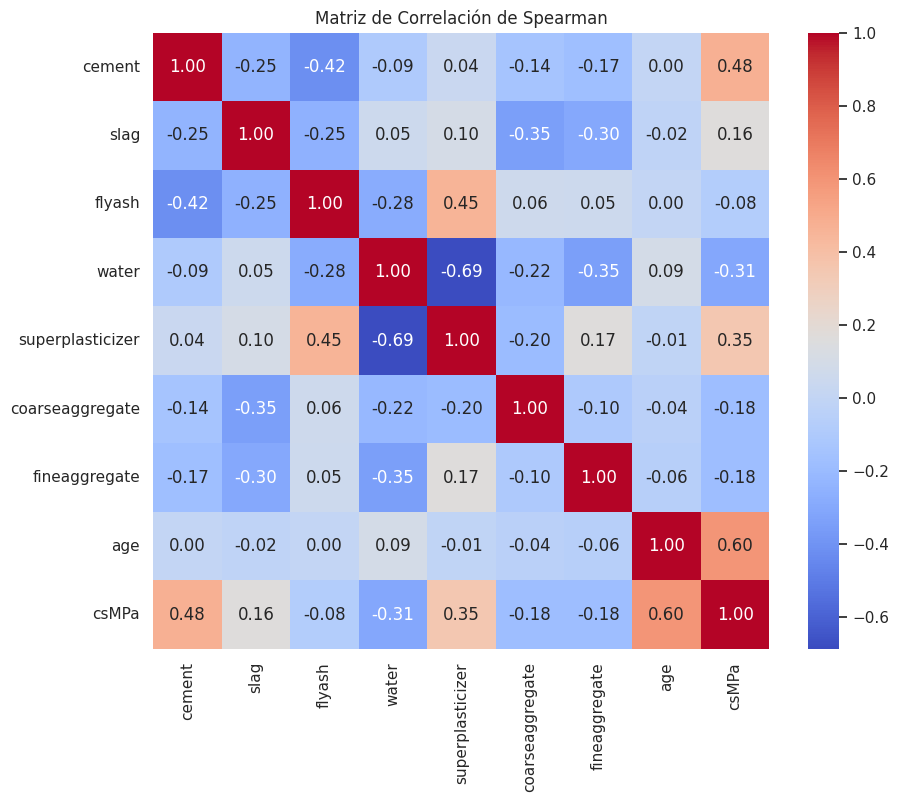

In [35]:
# @title Matriz de Correlación de Spearman
plt.figure(figsize=(10, 8))
corr_spearman = df_ccs.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación de Spearman')
plt.show()

Relaciones lineales
- El csMPa tiene buenas correlaciones con el cemento, el agua y la edad, lo cual tiene sentido segun la informacion recopilada.
- El superplastificante parece tener mucha correlacion con el agua (material suplementario del agua), ademas de influir mucho en nuestro target.
- La escoria (*slag*) y las cenizas volantes (*fly ash*) tienen correlacion con el cemento (materiales suplementarios del cemento).

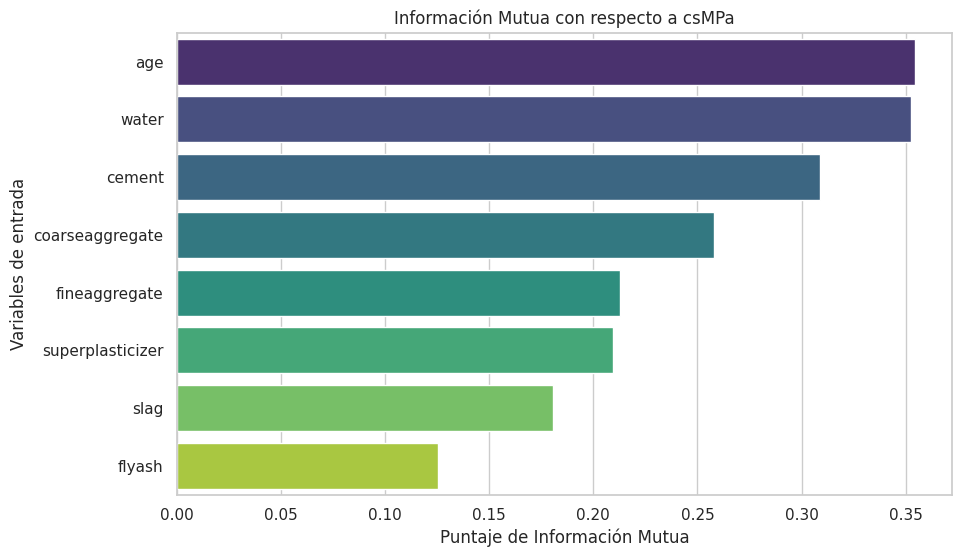

In [36]:
from sklearn.feature_selection import mutual_info_regression

# Preparar datos
X = df_ccs.drop('csMPa', axis=1)
y = df_ccs['csMPa']

# Calcular información mutua
mi_scores = mutual_info_regression(X, y, random_state=SEED)
mi_series = pd.Series(mi_scores, name="Información Mutua", index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette='viridis', legend=False)
plt.title('Información Mutua con respecto a csMPa')
plt.xlabel('Puntaje de Información Mutua')
plt.ylabel('Variables de entrada')
plt.show()

Informacion mutua
- Otra vez los mas influyentes son la edad, el cemento y el agua.
- El superplastificante bajo un poco, pero se mantiene en la ecuacion.

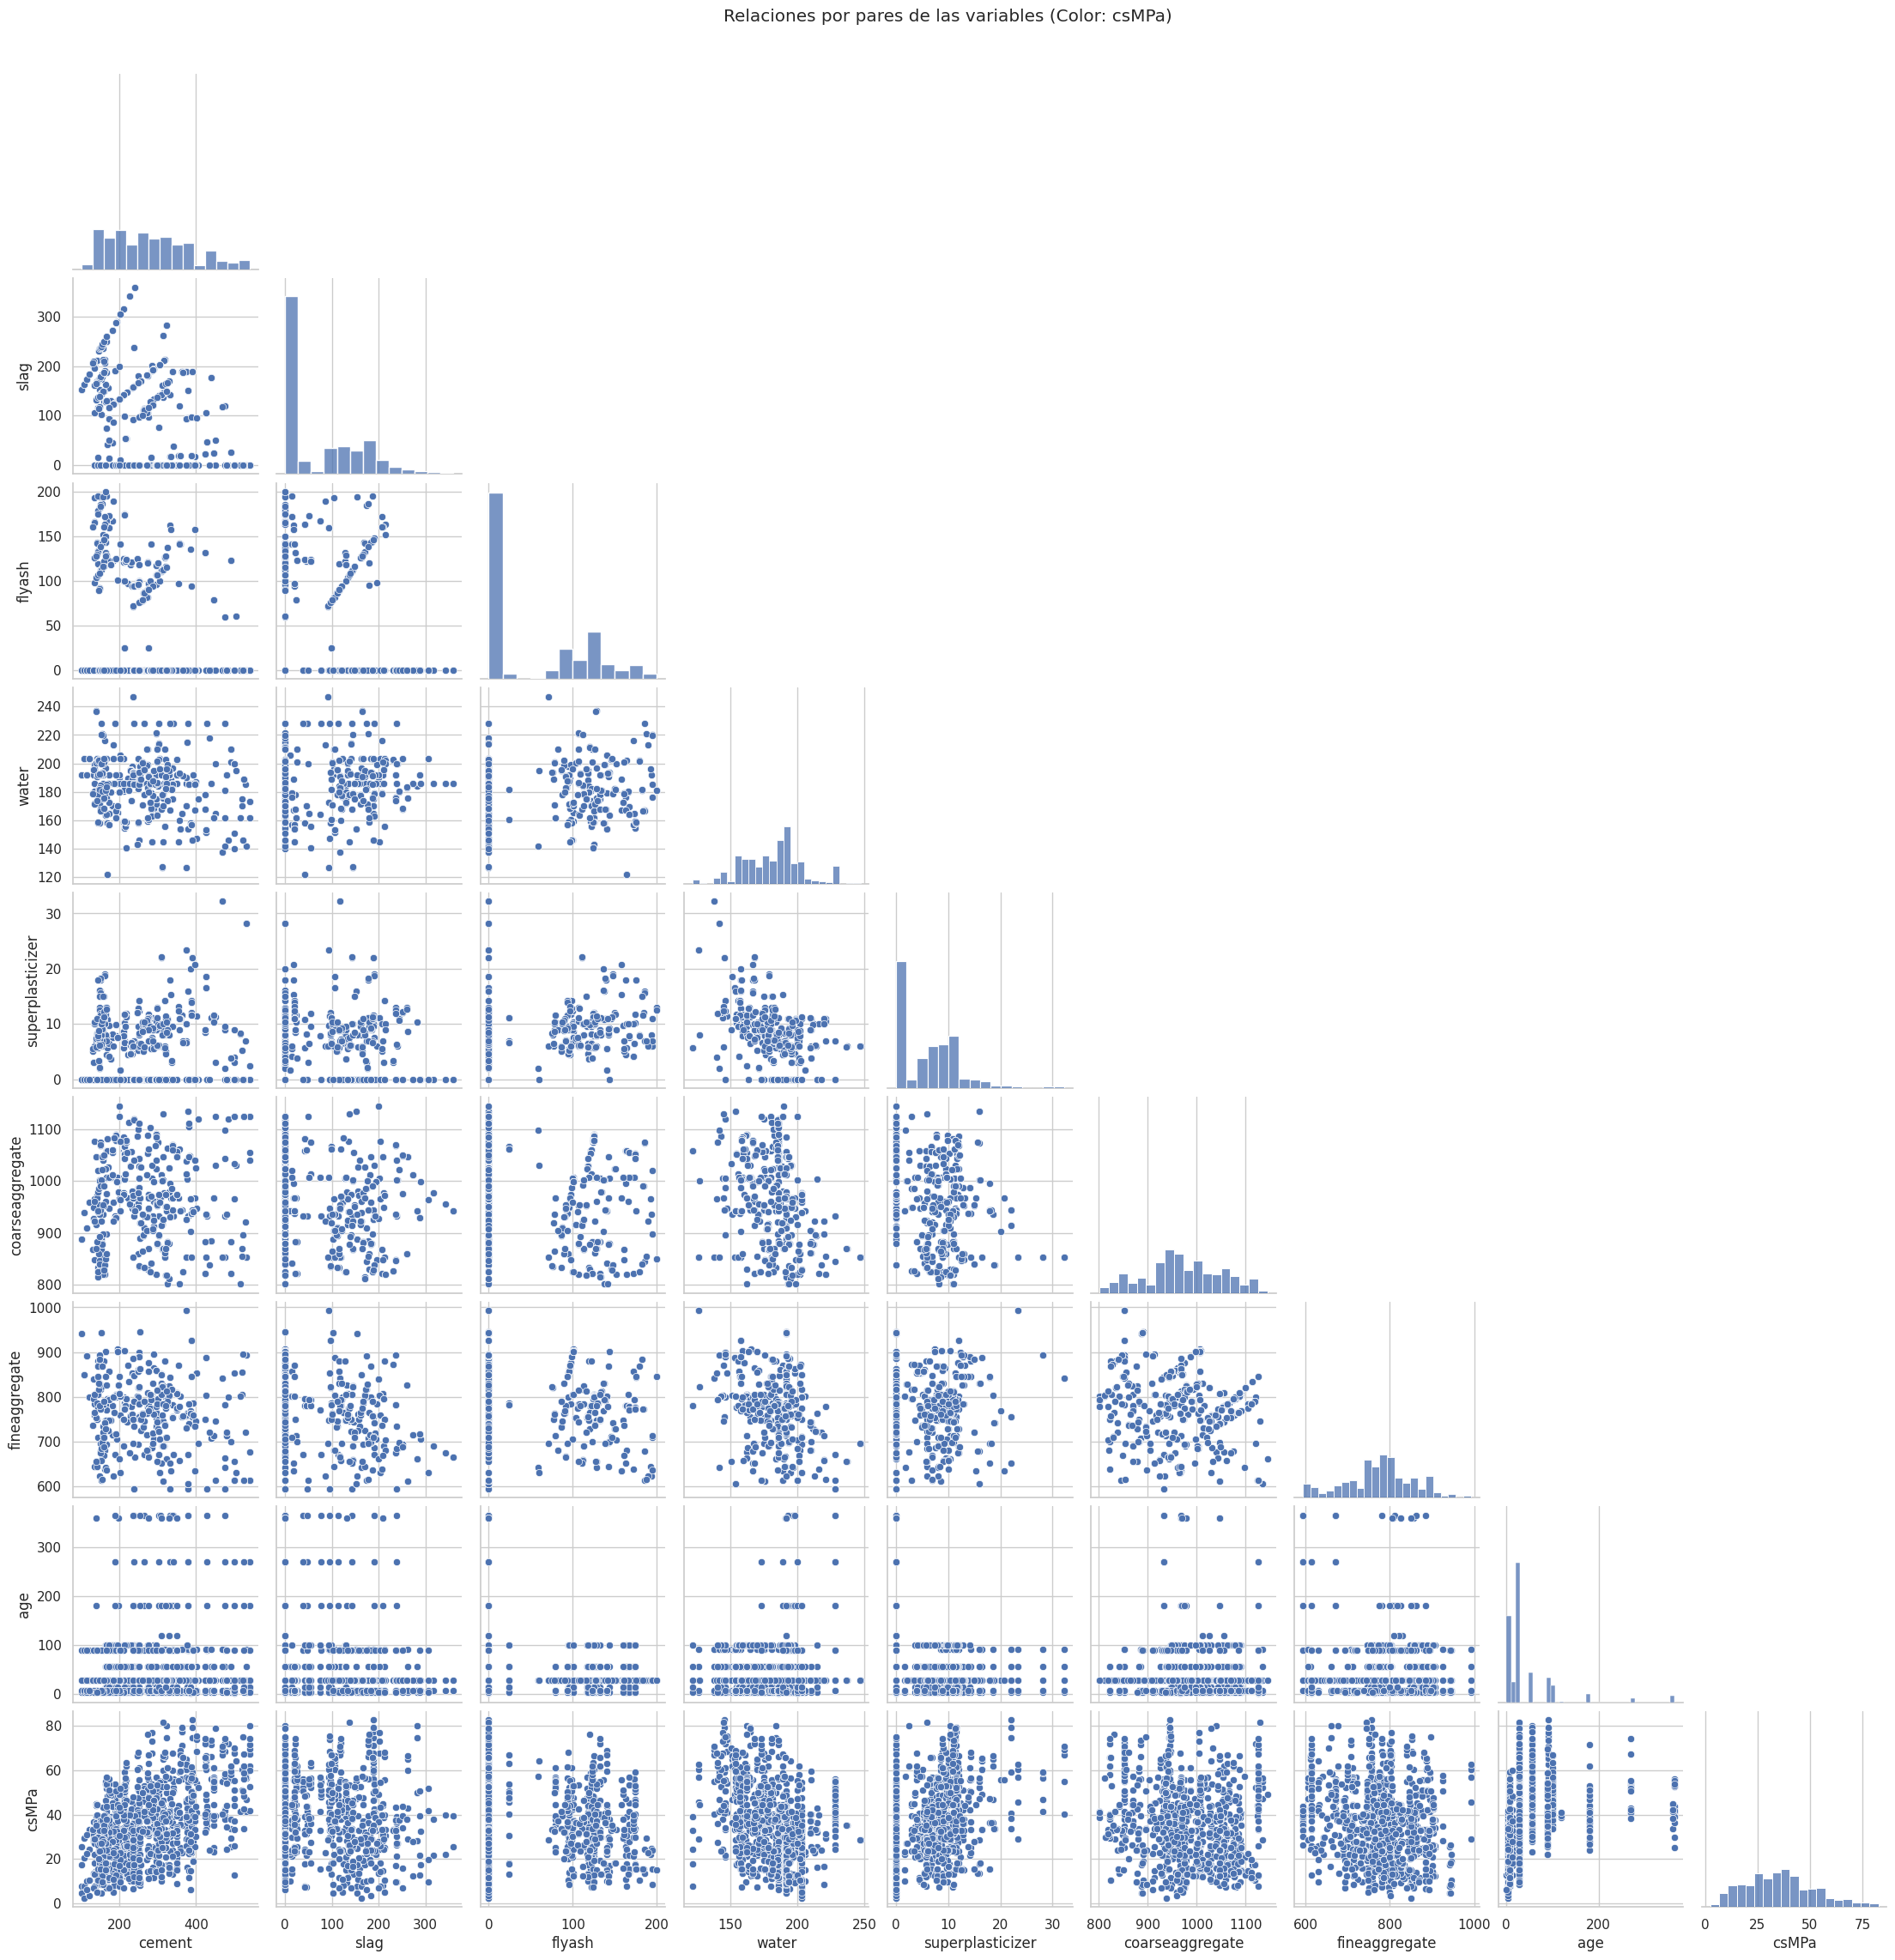

In [37]:
# Pairplot de las variables con el target como color
sns.pairplot(df_ccs, corner=True)
plt.suptitle('Relaciones por pares de las variables (Color: csMPa)', y=1.02)
plt.show()

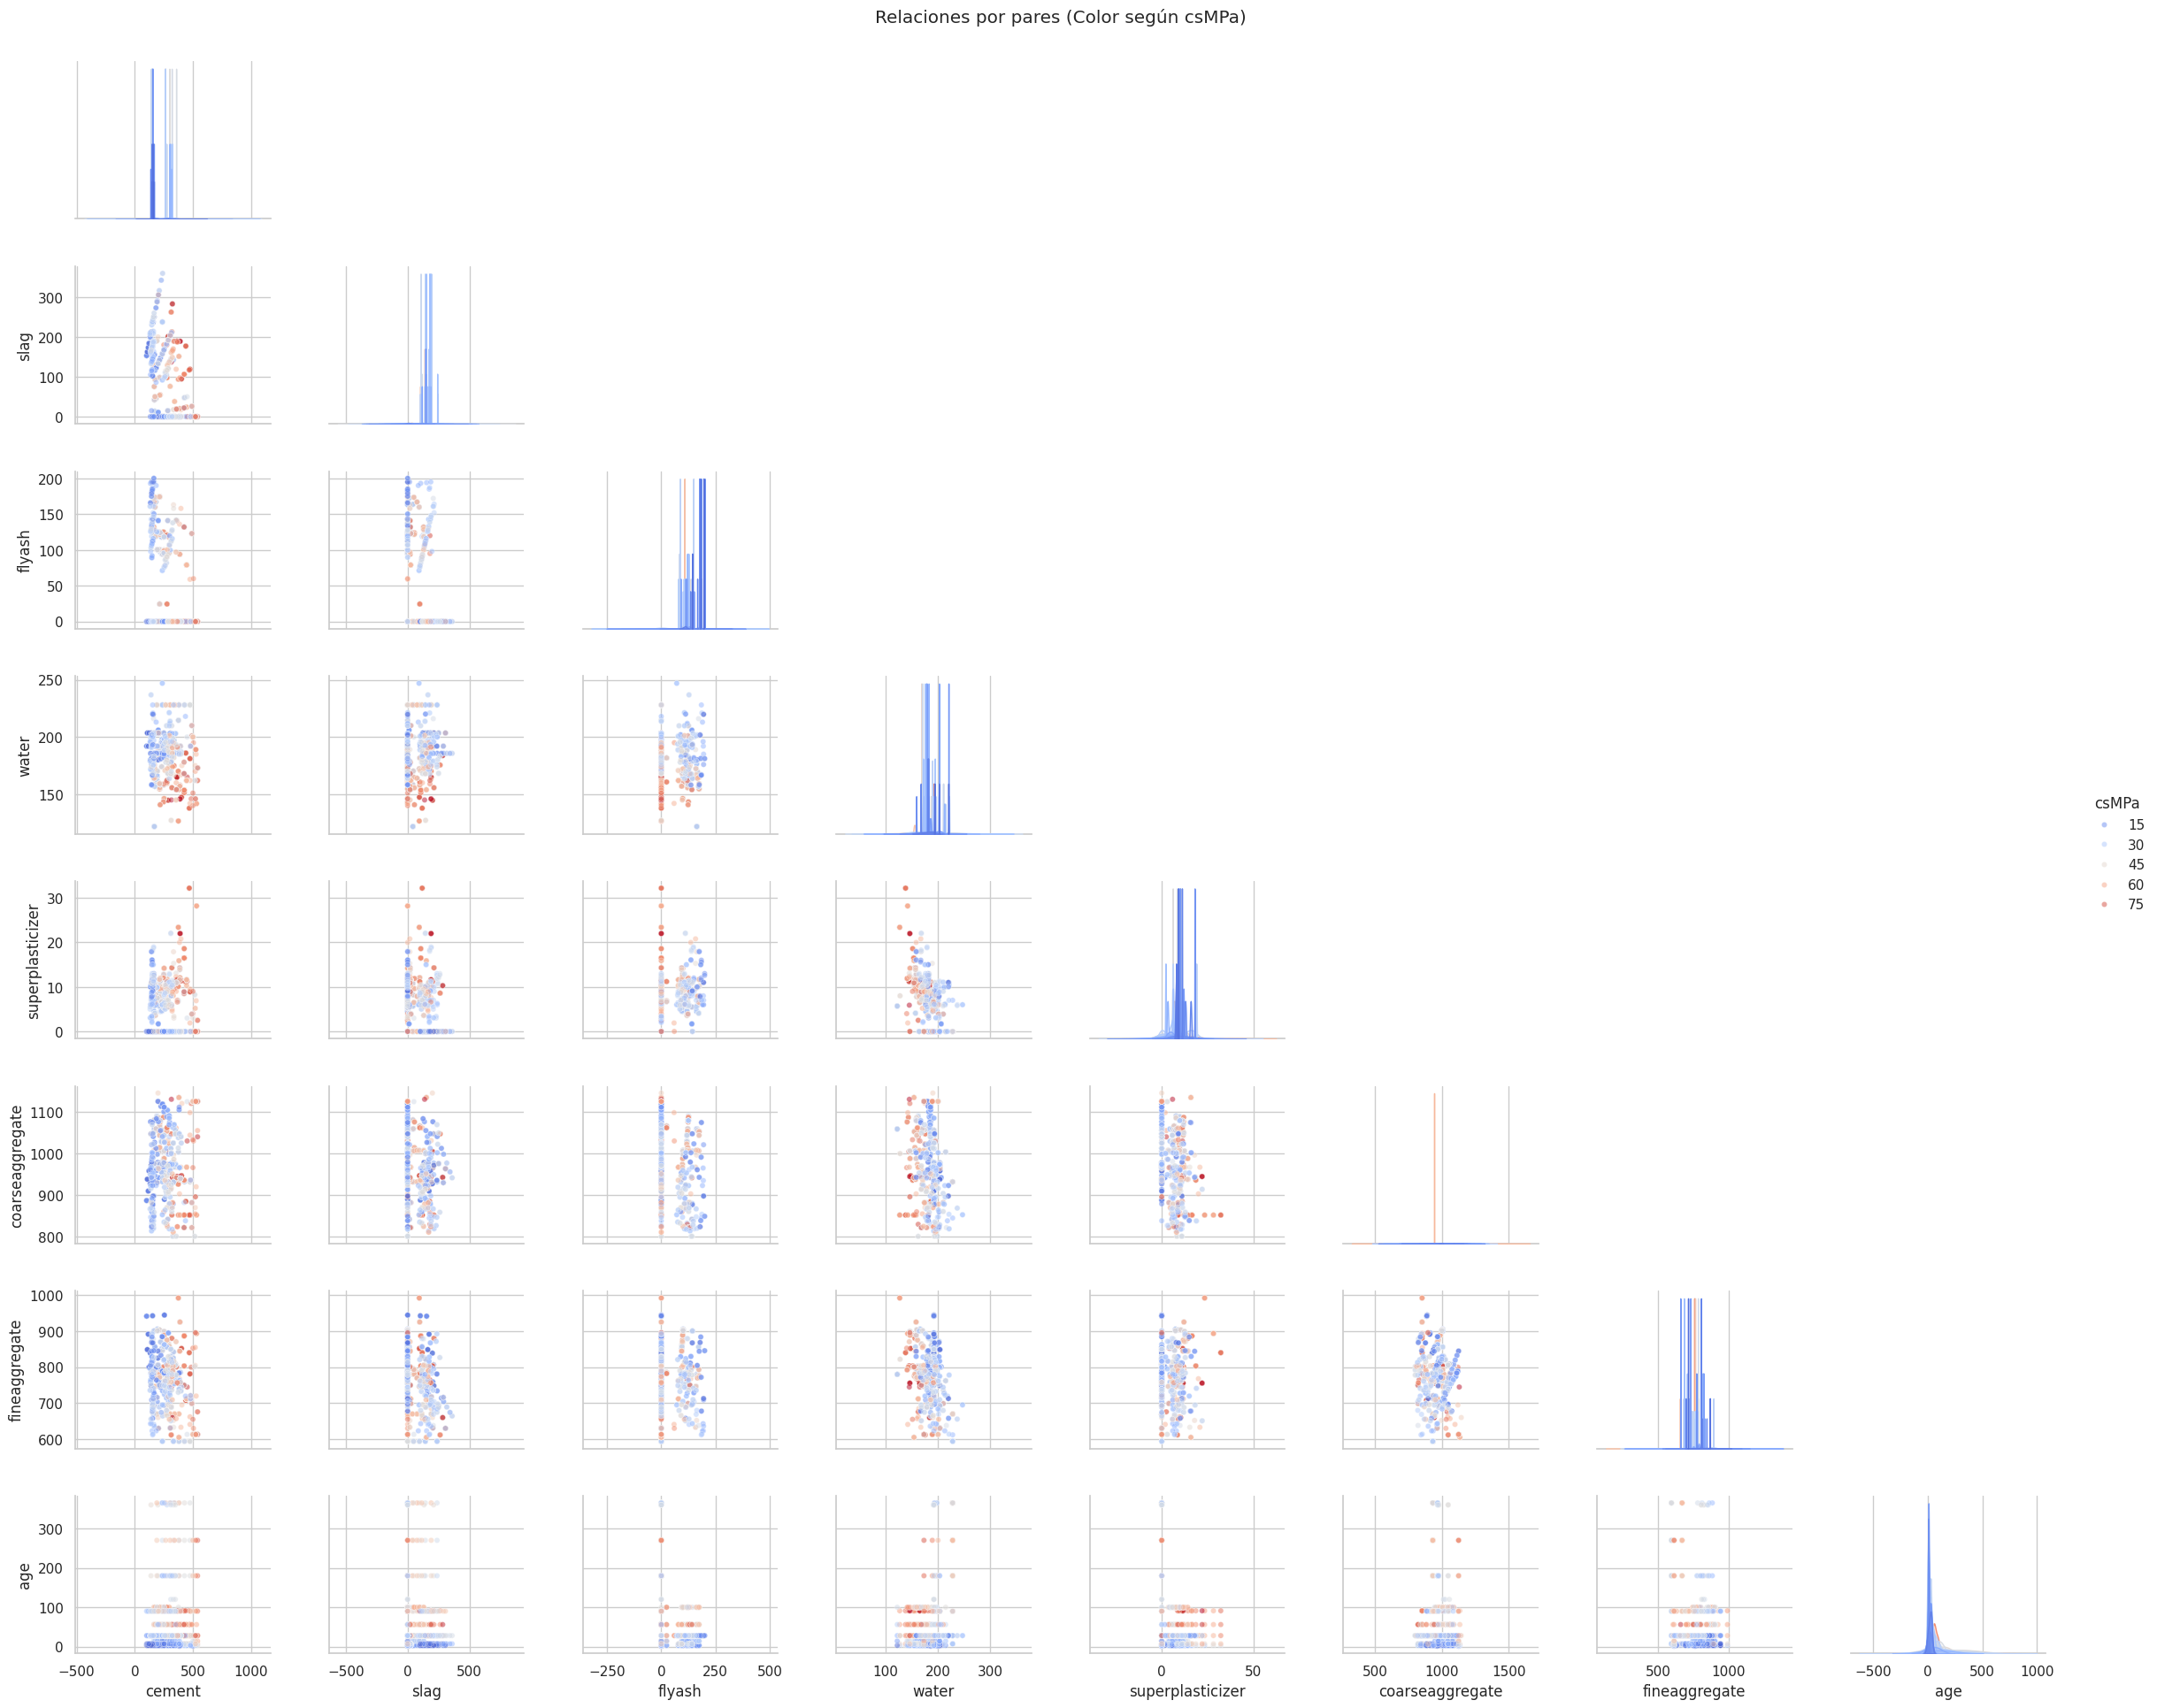

In [38]:
# @title Pairplot de variables (Hue: csMPa)
# Usamos corner=True y ajustamos el layout para que las escalas sean independientes por columna
g = sns.pairplot(df_ccs, hue='csMPa', palette='coolwarm', diag_kind='kde',
                 height=2.5, aspect=1.2,
                 plot_kws={'alpha': 0.5, 's': 20}, corner=True,
                 vars=[c for c in df_ccs.columns if c != 'csMPa'])

# Ajuste manual para evitar solapamiento y permitir que las escalas se vean bien
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.3)
plt.suptitle('Relaciones por pares (Color según csMPa)')
plt.show()

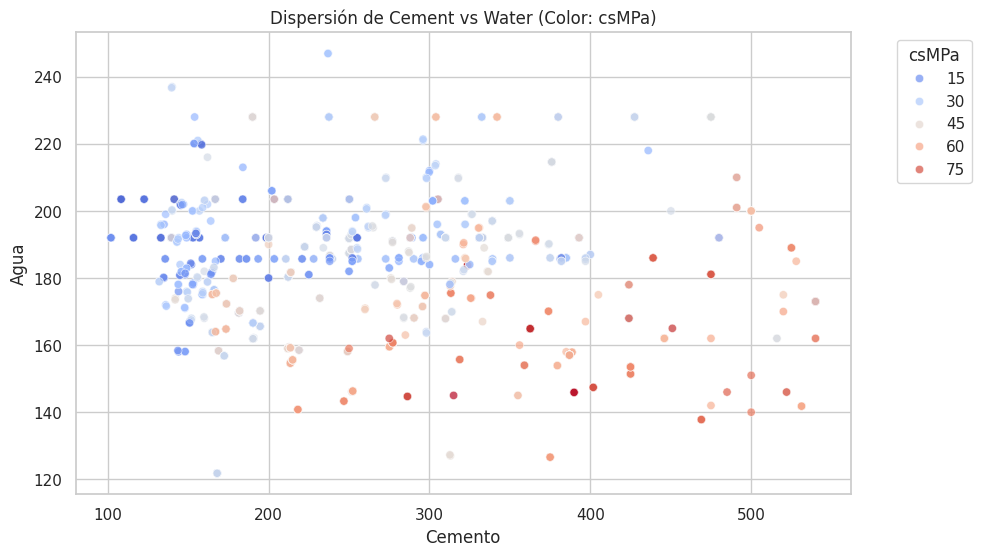

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='water', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Water (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Agua')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

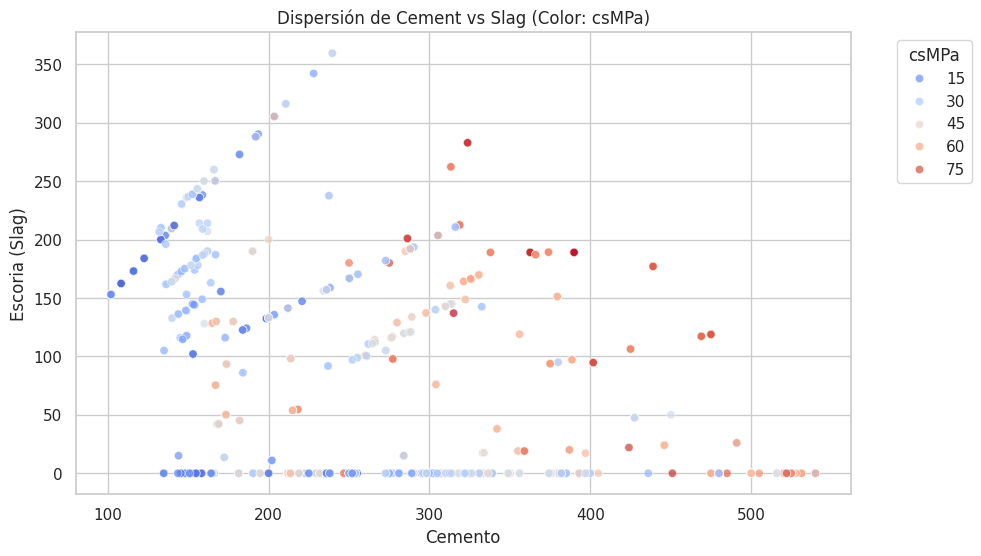

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='slag', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Slag (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Escoria (Slag)')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

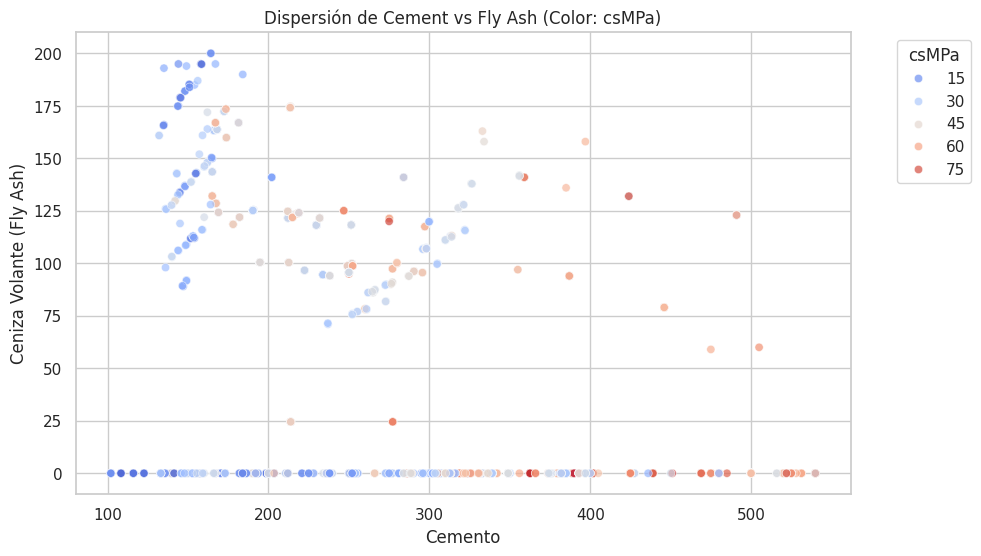

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='flyash', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Fly Ash (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Ceniza Volante (Fly Ash)')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

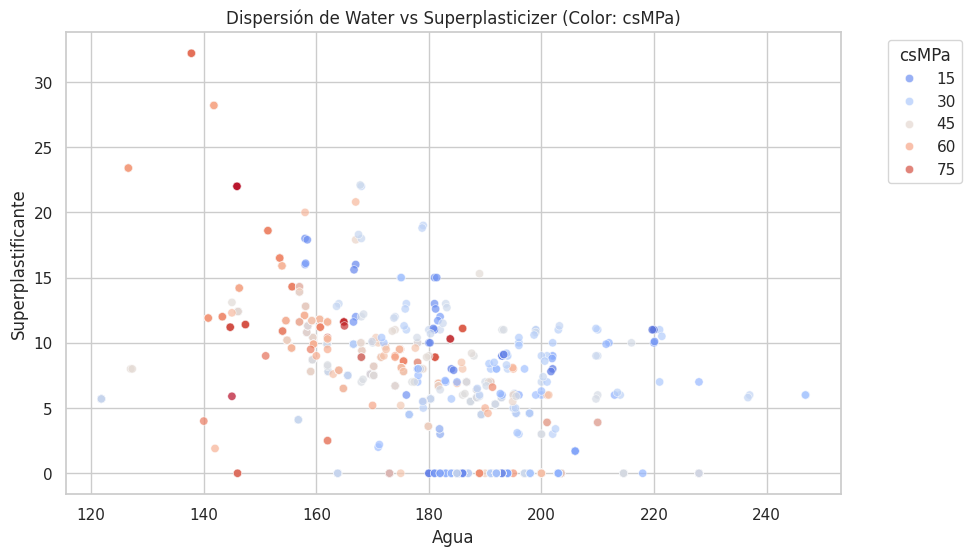

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='water', y='superplasticizer', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Water vs Superplasticizer (Color: csMPa)')
plt.xlabel('Agua')
plt.ylabel('Superplastificante')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##3 Etrenamiento

In [44]:
# Separamos Features (X) y Target (y)
X = df_ccs.drop(columns=['csMPa'])
y = df_ccs['csMPa']

# 2. División Train/Test INMEDIATA (Sin stratify porque es regresión)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

Seleccionamos los modelos:
- RandomForestRegressor
- LinearRegression
- KNeighborsRegression
- XGBRegression

--- Evaluación de Overfitting: LinearRegression ---
TRAIN - R2: 0.8013 | RMSE: 7.5126
TEST  - R2: 0.8162  | RMSE: 6.8821
MBE (Test): 0.0270


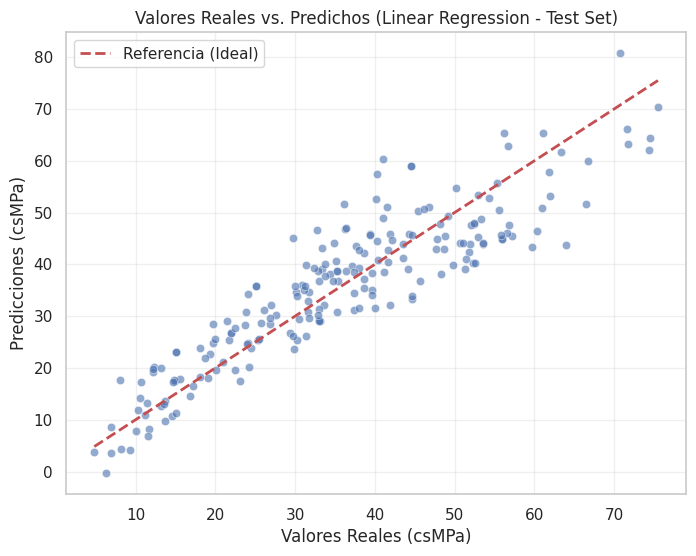

In [63]:
# 1. Definir el Pipeline: Preprocesamiento + Modelo
pipeline_lr = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('regressor', LinearRegression())
])

# 2. Entrenar el modelo
pipeline_lr.fit(X_train, y_train)

# 3. Realizar predicciones para Train y Test
y_pred_train = pipeline_lr.predict(X_train)
y_pred_test = pipeline_lr.predict(X_test)

# 4. Calcular métricas para evaluar Overfitting
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mbe_test = np.mean(y_pred_test - y_test)

print("--- Evaluación de Overfitting: LinearRegression ---")
print(f"TRAIN - R2: {r2_train:.4f} | RMSE: {rmse_train:.4f}")
print(f"TEST  - R2: {r2_test:.4f}  | RMSE: {rmse_test:.4f}")
print(f"MBE (Test): {mbe_test:.4f}")

# 5. Gráfico de dispersión: Valores Reales vs. Predichos (Test)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Referencia (Ideal)')
plt.title('Valores Reales vs. Predichos (Linear Regression - Test Set)')
plt.xlabel('Valores Reales (csMPa)')
plt.ylabel('Predicciones (csMPa)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Evaluación de Overfitting: KNN Regressor (k=5) ---
TRAIN - R2: 0.8256 | RMSE: 7.0388
TEST  - R2: 0.7188  | RMSE: 8.5117
MBE (Test): -1.0443


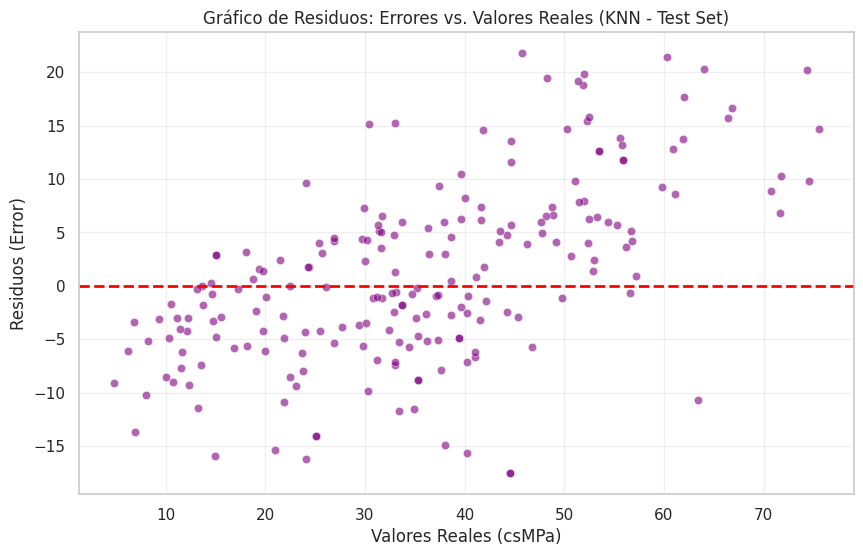

In [58]:
# 1. Definir el Pipeline: Escalado + Modelo KNN (n_neighbors fijo)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

# 2. Entrenar el modelo directamente sin GridSearchCV
knn_pipeline.fit(X_train, y_train)

# 3. Predicciones para Train y Test
y_pred_knn_train = knn_pipeline.predict(X_train)
y_pred_knn_test = knn_pipeline.predict(X_test)

# 4. Evaluación de Overfitting
r2_knn_train = r2_score(y_train, y_pred_knn_train)
rmse_knn_train = np.sqrt(mean_squared_error(y_train, y_pred_knn_train))

r2_knn_test = r2_score(y_test, y_pred_knn_test)
rmse_knn_test = np.sqrt(mean_squared_error(y_test, y_pred_knn_test))
mbe_knn_test = np.mean(y_pred_knn_test - y_test)

print("--- Evaluación de Overfitting: KNN Regressor (k=5) ---")
print(f"TRAIN - R2: {r2_knn_train:.4f} | RMSE: {rmse_knn_train:.4f}")
print(f"TEST  - R2: {r2_knn_test:.4f}  | RMSE: {rmse_knn_test:.4f}")
print(f"MBE (Test): {mbe_knn_test:.4f}")

# 5. Gráfico de Residuos (Set de Prueba)
residuos = y_test - y_pred_knn_test

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuos, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Gráfico de Residuos: Errores vs. Valores Reales (KNN - Test Set)')
plt.xlabel('Valores Reales (csMPa)')
plt.ylabel('Residuos (Error)')
plt.grid(True, alpha=0.3)
plt.show()

--- Evaluación de Overfitting: RandomForestRegressor ---
TRAIN - R2: 0.9865 | RMSE: 1.9619
TEST  - R2: 0.8816  | RMSE: 5.5232
MBE (Test): -0.8425


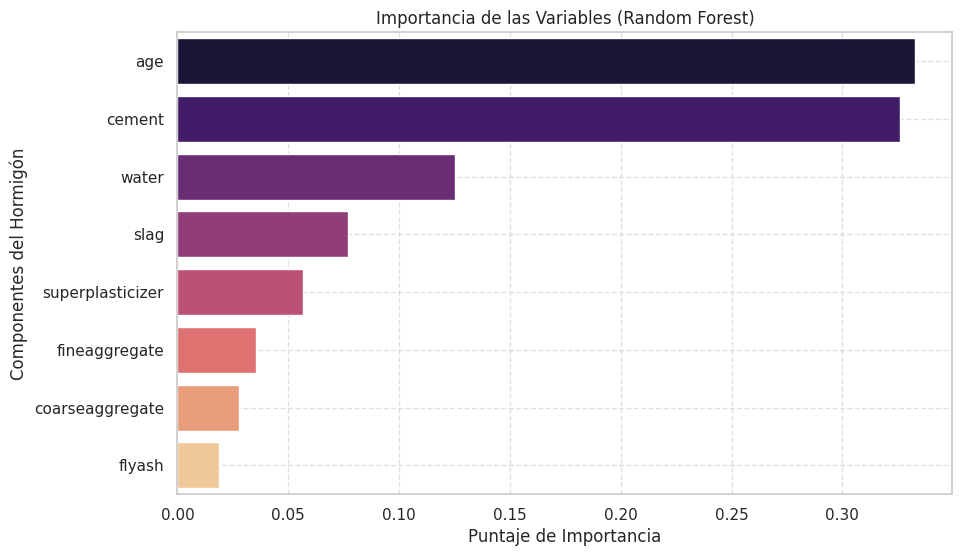

In [57]:
# 1. Inicializar y entrenar el modelo RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=SEED, max_depth=15)
rf_model.fit(X_train, y_train)

# 2. Realizar predicciones para Train y Test
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# 3. Calcular métricas de evaluación
r2_rf_train = r2_score(y_train, y_pred_rf_train)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))

r2_rf_test = r2_score(y_test, y_pred_rf_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mbe_rf_test = np.mean(y_pred_rf_test - y_test)

print("--- Evaluación de Overfitting: RandomForestRegressor ---")
print(f"TRAIN - R2: {r2_rf_train:.4f} | RMSE: {rmse_rf_train:.4f}")
print(f"TEST  - R2: {r2_rf_test:.4f}  | RMSE: {rmse_rf_test:.4f}")
print(f"MBE (Test): {mbe_rf_test:.4f}")

# 4. Extraer Feature Importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Componente': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# 5. Generar gráfico de barras de importancia de variables
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importancia', y='Componente', palette='magma', hue='Componente', legend=False)
plt.title('Importancia de las Variables (Random Forest)')
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Componentes del Hormigón')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Evaluación de Overfitting: XGBoost Regressor ---
TRAIN - R2: 0.9903 | RMSE: 1.6583
TEST  - R2: 0.9179  | RMSE: 4.5999
MBE (Test): -0.7190
Tasa de Riesgo por Sobreestimación: 44.17%


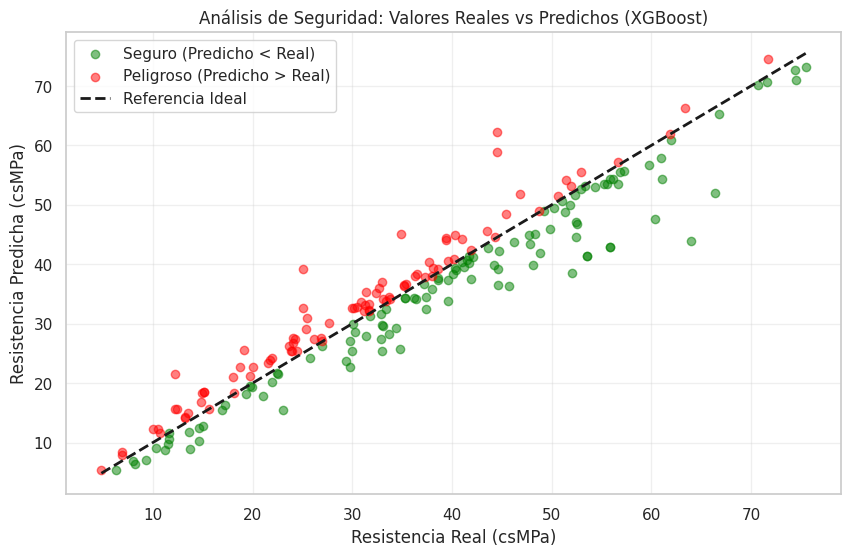

In [61]:
# 1. Configurar y entrenar el modelo XGBoost con parámetros conservadores
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    random_state=SEED
)
xgb_model.fit(X_train, y_train)

# 2. Predicciones para Train y Test
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

# 3. Cálculo de métricas para evaluar Overfitting
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))

r2_xgb_test = r2_score(y_test, y_pred_xgb_test)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mbe_xgb_test = np.mean(y_pred_xgb_test - y_test)

# 4. Cálculo de Tasa de Riesgo por Sobreestimación (Predicho > Real)
overestimation_mask = y_pred_xgb_test > y_test
risk_rate = (overestimation_mask.sum() / len(y_test)) * 100

print("--- Evaluación de Overfitting: XGBoost Regressor ---")
print(f"TRAIN - R2: {r2_xgb_train:.4f} | RMSE: {rmse_xgb_train:.4f}")
print(f"TEST  - R2: {r2_xgb_test:.4f}  | RMSE: {rmse_xgb_test:.4f}")
print(f"MBE (Test): {mbe_xgb_test:.4f}")
print(f"Tasa de Riesgo por Sobreestimación: {risk_rate:.2f}%")

# 5. Visualización de Seguridad Estructural
plt.figure(figsize=(10, 6))

# Puntos seguros (Predicho <= Real) en verde
plt.scatter(y_test[~overestimation_mask], y_pred_xgb_test[~overestimation_mask],
            color='green', alpha=0.5, label='Seguro (Predicho < Real)')

# Puntos peligrosos (Predicho > Real) en rojo
plt.scatter(y_test[overestimation_mask], y_pred_xgb_test[overestimation_mask],
            color='red', alpha=0.5, label='Peligroso (Predicho > Real)')

# Línea de identidad
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'k--', lw=2, label='Referencia Ideal')

plt.title('Análisis de Seguridad: Valores Reales vs Predichos (XGBoost)')
plt.xlabel('Resistencia Real (csMPa)')
plt.ylabel('Resistencia Predicha (csMPa)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()